In [2]:
#import needed tools
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [8]:
#load our data
df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [9]:
# features and target
X = df.drop("Class", axis=1)
y = df["Class"]

In [10]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Apply SMOTE only on train
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train,y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts())
# Now Class is Balanced

Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


## Introducing our models and their evaluations

In [15]:
# 1. XGBOOST MODEL

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(),  # imbalance handling
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_resampled, y_train_resampled)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [16]:
# Predictions
y_pred_xgb_model = xgb_model.predict(X_test)
y_probs_xgb_model = xgb_model.predict_proba(X_test)[:, 1]

In [33]:
# Evaluation
print("=== XGBOOST RESULTS ===")
xgb_model_baseline_ras = roc_auc_score(y_test, y_pred_xgb_model)
xgb_model_baseline_cr = classification_report(y_test, y_pred_xgb_model)
xgb_model_baseline_cm = confusion_matrix(y_test, y_pred_xgb_model)
print("xgb_model_baseline_ras:\n:", xgb_model_baseline_ras)
print("xgb_model_baseline_cr:\n:", xgb_model_baseline_cr)
print("xgb_model_baseline_cm:\n", xgb_model_baseline_cm)

=== XGBOOST RESULTS ===
xgb_model_baseline_ras:
: 0.9327502139009796
xgb_model_baseline_cr:
:               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.45      0.87      0.59        98

    accuracy                           1.00     56962
   macro avg       0.72      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962

xgb_model_baseline_cm:
 [[56759   105]
 [   13    85]]


In [22]:
# 2. LIGHTGBM MODEL

lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    class_weight="balanced",
    random_state=42
)

lgb_model.fit(X_train_resampled, y_train_resampled)

[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.258130 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [23]:
# Predictions
y_pred_lgb_model = lgb_model.predict(X_test)
y_proba_lgb_model = lgb_model.predict_proba(X_test)[:, 1]

In [31]:
# Evaluation
print("\n=== LIGHTGBM RESULTS ===")
lgb_model_baseline_ras = roc_auc_score(y_test, y_proba_lgb_model)
lgb_model_baseline_cr = classification_report(y_test, y_pred_lgb_model)
lgb_model_baseline_cm = confusion_matrix(y_test, y_pred_lgb_model)
print("ROC-AUC SCORE:", lgb_model_baseline_ras)
print("CLASSIFICATION REPORT:\n",lgb_model_baseline_cr)
print("CONFUSION MATRIX:\n", lgb_model_baseline_cm)


=== LIGHTGBM RESULTS ===
ROC-AUC SCORE: 0.9756093665659848
CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.85      0.83        98

    accuracy                           1.00     56962
   macro avg       0.91      0.92      0.91     56962
weighted avg       1.00      1.00      1.00     56962

CONFUSION MATRIX:
 [[56845    19]
 [   15    83]]


## Advanced hyperparamer tuning

In [35]:
# LIGHTGBM HYPERPARAMETER SEARCH
from sklearn.model_selection import RandomizedSearchCV

lgb = LGBMClassifier(random_state=42)

param_dist = {
     "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.03, 0.05],
    "num_leaves": [20, 31, 50],
    "max_depth": [-1, 10, 20],
    "min_child_samples": [20, 50, 100],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

search_lgb = RandomizedSearchCV(
    lgb,
    param_distributions=param_dist,
    n_iter=10,
    scoring="f1", # optimizing for f1, balance between precision and recall
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
search_lgb.fit(X_train_resampled, y_train_resampled)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.199816 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

,estimator,LGBMClassifie...ndom_state=42)
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [-1, 10, ...], 'min_child_samples': [20, 50, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [36]:
best_lgb = search_lgb.best_estimator_

In [37]:
y_pred_best_lgb = best_lgb.predict(X_test)
y_proba_best_lgb = best_lgb.predict_proba(X_test)[:, 1]

In [38]:
# Evaluation
print("\n=== ADVANCED LIGHTGBM RESULTS ===")
best_lgb_advanced_ras = roc_auc_score(y_test, y_proba_best_lgb)
best_lgb_advanced_cr = classification_report(y_test, y_pred_best_lgb)
best_lgb_advanced_cm = confusion_matrix(y_test, y_pred_best_lgb)
print("ROC-AUC SCORE:", best_lgb_advanced_ras)
print("CLASSIFICATION REPORT:\n",best_lgb_advanced_cr)
print("CONFUSION MATRIX:\n", best_lgb_advanced_cm)


=== ADVANCED LIGHTGBM RESULTS ===
ROC-AUC SCORE: 0.9843001705465528
CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.85      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

CONFUSION MATRIX:
 [[56848    16]
 [   15    83]]


In [39]:
# 2. Advanced Tuning (XGBoost)

xgb = XGBClassifier(random_state=42, n_jobs=-1)

param_dist_xgb = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "scale_pos_weight": [1, 5, 10]
}

search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_xgb.fit(X_train_resampled, y_train_resampled)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [4, 6, ...], 'n_estimators': [300, 500, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [40]:
best_xgb = search_xgb.best_estimator_

In [41]:
y_pred_best_xgb = best_xgb.predict(X_test)
y_proba_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

In [42]:
# Evaluation
print("\n=== ADVANCED XGBOOST RESULTS ===")
best_xgb_advanced_ras = roc_auc_score(y_test, y_proba_best_xgb)
best_xgb_advanced_cr = classification_report(y_test, y_pred_best_xgb)
best_xgb_advanced_cm = confusion_matrix(y_test, y_pred_best_xgb)
print("ROC-AUC SCORE:", best_xgb_advanced_ras)
print("CLASSIFICATION REPORT:\n",best_xgb_advanced_cr)
print("CONFUSION MATRIX:\n", best_xgb_advanced_cm)


=== ADVANCED XGBOOST RESULTS ===
ROC-AUC SCORE: 0.9852393968279489
CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.86      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.92     56962
weighted avg       1.00      1.00      1.00     56962

CONFUSION MATRIX:
 [[56847    17]
 [   14    84]]


In [46]:
threshold = 0.3  # experiment

y_pred_custom = (best_xgb.predict_proba(X_test)[:, 1] >= threshold).astype(int)

In [47]:
print("\n=== _ADVANCED XGBOOST RESULTS ===")
_best_xgb_advanced_ras = roc_auc_score(y_test, y_pred_custom)
_best_xgb_advanced_cr = classification_report(y_test, y_pred_custom)
_best_xgb_advanced_cm = confusion_matrix(y_test, y_pred_custom)
print("ROC-AUC SCORE:", _best_xgb_advanced_ras)
print("CLASSIFICATION REPORT:\n",_best_xgb_advanced_cr)
print("CONFUSION MATRIX:\n", _best_xgb_advanced_cm)


=== _ADVANCED XGBOOST RESULTS ===
ROC-AUC SCORE: 0.933480025381002
CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.87      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962

CONFUSION MATRIX:
 [[56842    22]
 [   13    85]]


* Threshold wasnt helpful
* Tested threshold optimization to increase recall, but observed a drop in precision and F1-score. Chose to retain the default threshold as it provided the best balance between fraud detection and false positives.

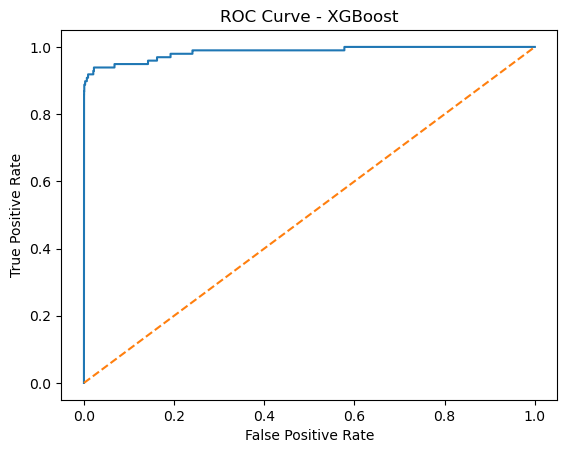

In [49]:
# roc_curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.show()

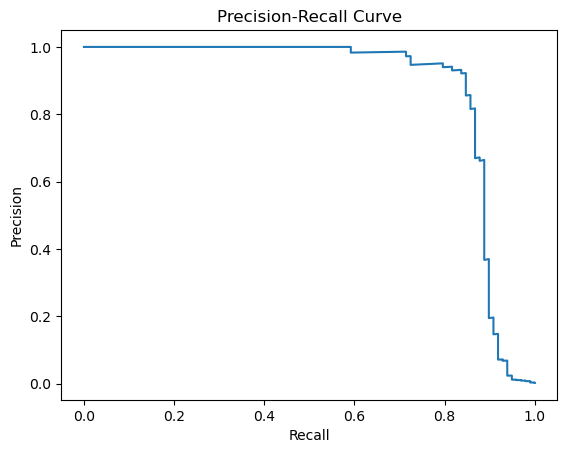

In [50]:
# precision recall curve
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

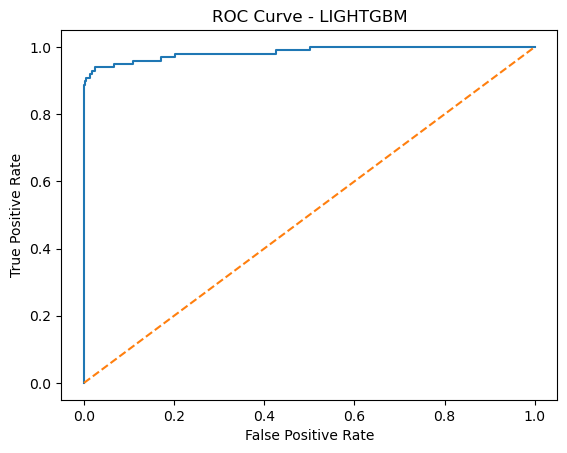

In [51]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, best_lgb.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LIGHTGBM")
plt.show()

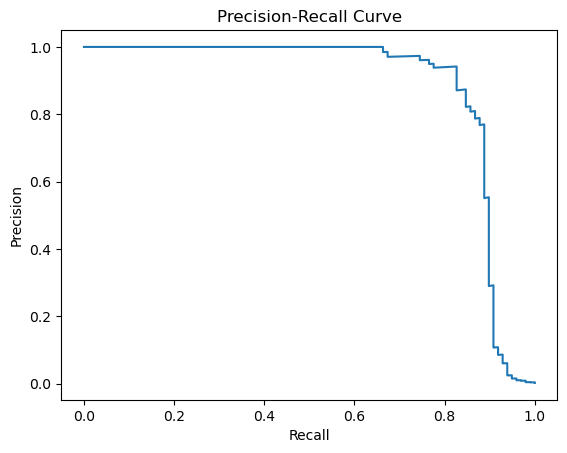

In [52]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, best_lgb.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

### Optimized XGBoost and LightGBM models for fraud detection, 
achieving
* ~0.985 ROC-AUC 
* with balanced precision (~0.83–0.84)
* and recall (~0.85–0.86),
*  minimizing both false negatives (missed fraud) and false positives.

## 🧠 So… Which Model Wins?
* 🛡️ For Fraud / Security Systems:

👉 XGBoost wins

Why?

Misses less fraud (14 vs 15)
Even 1 extra fraud caught = $$$ saved
* 👤 For User Experience:

👉 LightGBM wins

Why?

Fewer false alarms (16 vs 17)
Slightly cleaner predictions

## FEATURE IMPORTANCE

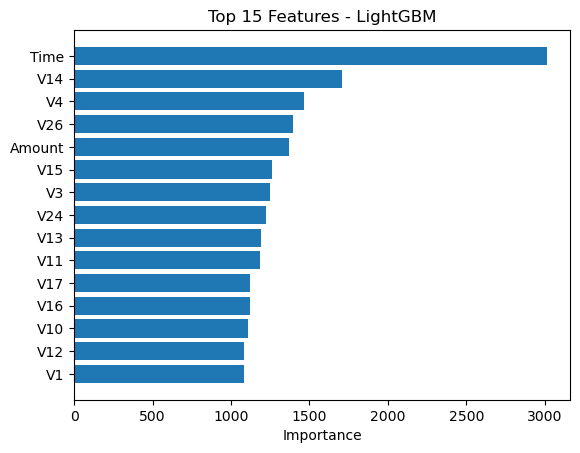

In [57]:
# ================================
# LIGHTGBM FEATURE IMPORTANCE
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get importance
lgb_importance = best_lgb.feature_importances_
features = X.columns

# Create dataframe
lgb_df = pd.DataFrame({
    "feature": features,
    "importance": lgb_importance
}).sort_values("importance", ascending=False)

# Top 15
top_lgb = lgb_df.head(15)

# Plot
plt.figure()
plt.barh(top_lgb["feature"][::-1], top_lgb["importance"][::-1])
plt.title("Top 15 Features - LightGBM")
plt.xlabel("Importance")
plt.show()

# Save
lgb_df.to_csv("../models/lgb_feature_importance.csv", index=False)

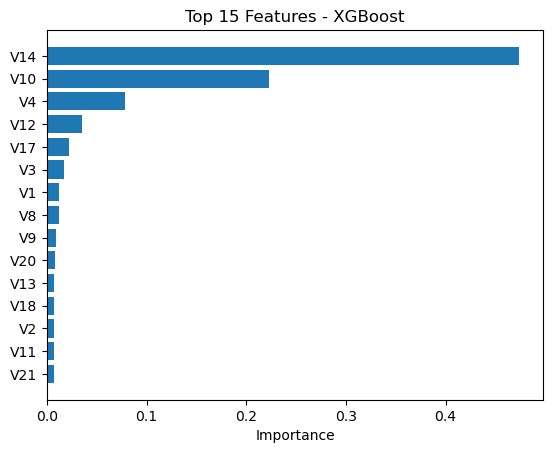

In [56]:
# ================================
# XGBOOST FEATURE IMPORTANCE
# ================================
xgb_importance = best_xgb.feature_importances_

xgb_df = pd.DataFrame({
    "feature": features,
    "importance": xgb_importance
}).sort_values("importance", ascending=False)

top_xgb = xgb_df.head(15)

plt.figure()
plt.barh(top_xgb["feature"][::-1], top_xgb["importance"][::-1])
plt.title("Top 15 Features - XGBoost")
plt.xlabel("Importance")
plt.show()

# Save
xgb_df.to_csv("../models/xgb_feature_importance.csv", index=False)

In [58]:
import joblib

joblib.dump(best_lgb, "../models/best_lightgbm.pkl")
joblib.dump(best_xgb, "../models/best_xgboost.pkl")

['../models/best_xgboost.pkl']

## DEPLOYMENT (API)

In [ ]:
# xgboost model
